In [2]:
import os
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ==========================================
# 1. 스타일 설정 (논문용 깔끔한 스타일)
# ==========================================
mpl.rcParams['font.family'] = 'Times New Roman' # 한글 폰트가 필요하면 변경 (예: 'Malgun Gothic')
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.size'] = 14
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['lines.linewidth'] = 2.0
mpl.rcParams['figure.dpi'] = 300

# ==========================================
# 2. 결과 데이터 로드 및 에러 계산 함수
# ==========================================
def parse_re_from_filename(filename):
    """파일명에서 Re 값 추출 (예: ...Re50.0.txt -> 50.0)"""
    match = re.search(r"Re([\d\.]+)\.txt", filename)
    return float(match.group(1)) if match else None

def compute_relative_l2(pred, exact):
    """Relative L2 Error 계산"""
    # 벡터 형태(N, 1) 혹은 (N,) 등으로 들어올 수 있음
    diff = pred.flatten() - exact.flatten()
    norm_diff = np.linalg.norm(diff)
    norm_exact = np.linalg.norm(exact.flatten())
    if norm_exact < 1e-9: return 0.0
    return norm_diff / norm_exact

def load_all_results(root_dir="./results"):
    """
    구조: results/{layers}_{neurons}/{KEY}/...
    반환: data[arch][model_type] = {Re: error, ...}
    """
    data_summary = {} # { "3_8": {"LPA": {50.0: 0.01, ...}, "VAN": ...}, "3_16": ... }

    # 1. 아키텍처 폴더 탐색 (예: 3_8, 3_16 ...)
    arch_folders = sorted(glob.glob(os.path.join(root_dir, "*_*")))

    for arch_path in arch_folders:
        arch_name = os.path.basename(arch_path) # "3_8"
        if not re.match(r"\d+_\d+", arch_name): continue

        data_summary[arch_name] = {}

        # 2. 모델 타입 폴더 탐색 (DeepONet_PINN_B_LPA 등)
        model_folders = glob.glob(os.path.join(arch_path, "DeepONet_*"))
        
        for model_path in model_folders:
            model_dir_name = os.path.basename(model_path)
            
            # 모델 타입 식별 (LPA vs VAN)
            if "LPA" in model_dir_name:
                m_type = "LPA"
            elif "VAN" in model_dir_name:
                m_type = "VAN"
            else:
                continue
            
            data_summary[arch_name][m_type] = {}

            # 3. 예측/정답 파일 쌍 찾기
            pred_files = glob.glob(os.path.join(model_path, "prediction_*_Re*.txt"))
            
            for f_pred in pred_files:
                re_val = parse_re_from_filename(f_pred)
                if re_val is None: continue

                # 대응되는 exact 파일 찾기
                f_exact = f_pred.replace("prediction_", "exact_")
                
                if not os.path.exists(f_exact):
                    # exact 파일이 없으면 계산 스킵 (혹은 별도 계산 로직 필요)
                    continue

                try:
                    # 데이터 로드 (csv 형태 가정)
                    pred_data = np.loadtxt(f_pred, delimiter=',')
                    exact_data = np.loadtxt(f_exact, delimiter=',')
                    
                    # u, v, p가 합쳐져 있을 수 있음 (여기서는 전체 벡터에 대한 L2 계산)
                    # 만약 u만 보고 싶다면 인덱싱 필요 (예: pred_data[:, 0])
                    # 여기서는 전체 필드(u,v,p 통합) 에러를 계산합니다.
                    err = compute_relative_l2(pred_data, exact_data)
                    data_summary[arch_name][m_type][re_val] = err
                except Exception as e:
                    print(f"Error loading {f_pred}: {e}")

    return data_summary


In [3]:
# ==========================================
# 3. 데이터 로딩 실행
# ==========================================
results_root = "./results"  # 결과가 저장된 루트 폴더
all_data = load_all_results(results_root)

print("Loaded Architectures:", list(all_data.keys()))
for arch in all_data:
    print(f"  [{arch}] Models: {list(all_data[arch].keys())}")

Loaded Architectures: ['3_16', '3_32', '3_64', '3_8']
  [3_16] Models: ['LPA', 'VAN']
  [3_32] Models: ['LPA', 'VAN']
  [3_64] Models: ['LPA', 'VAN']
  [3_8] Models: ['LPA', 'VAN']


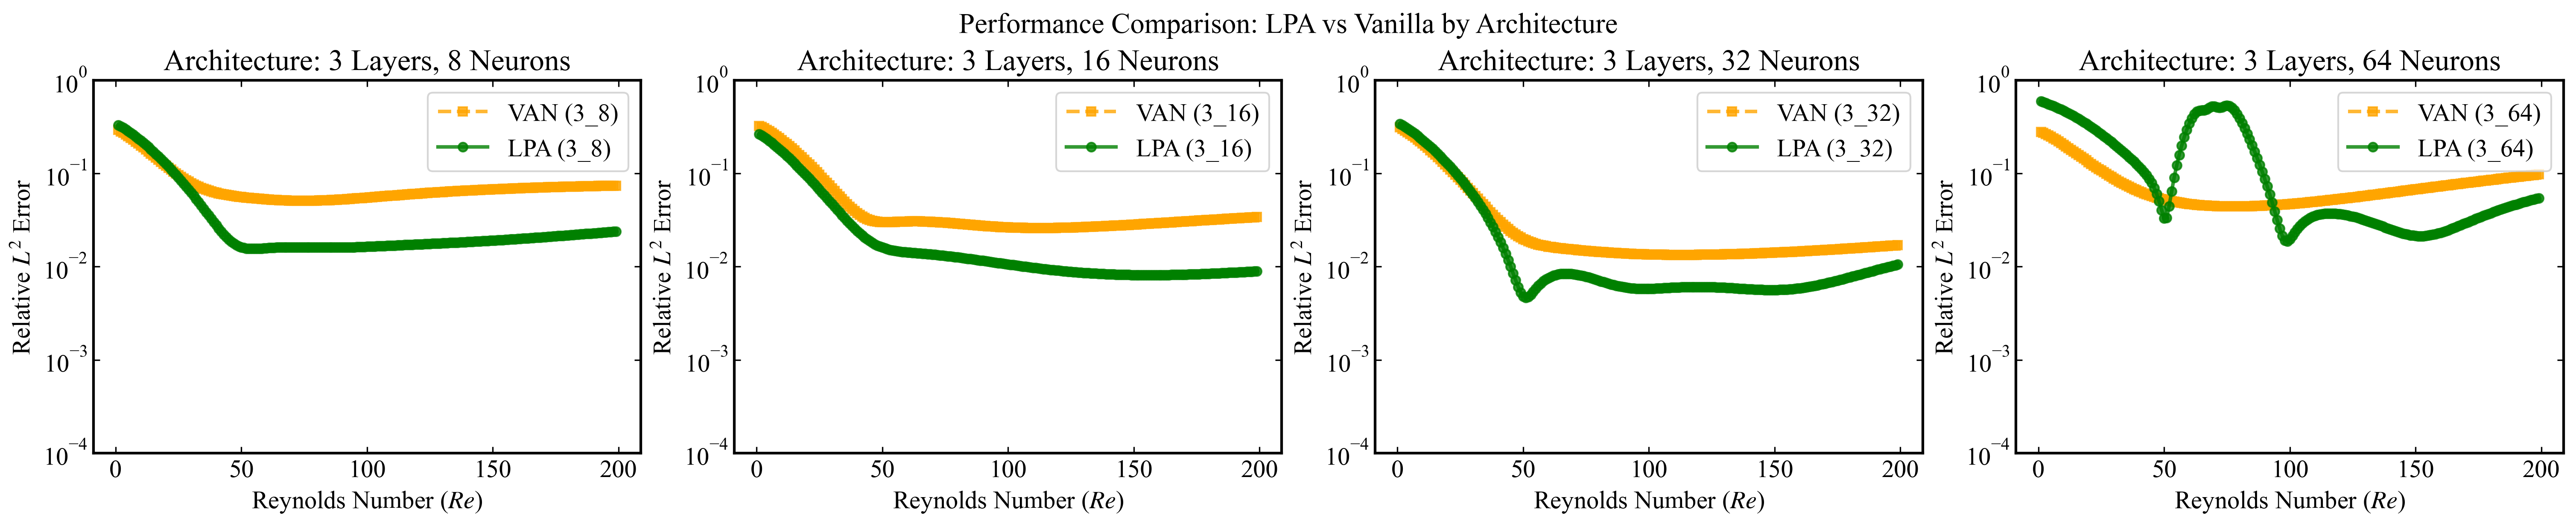

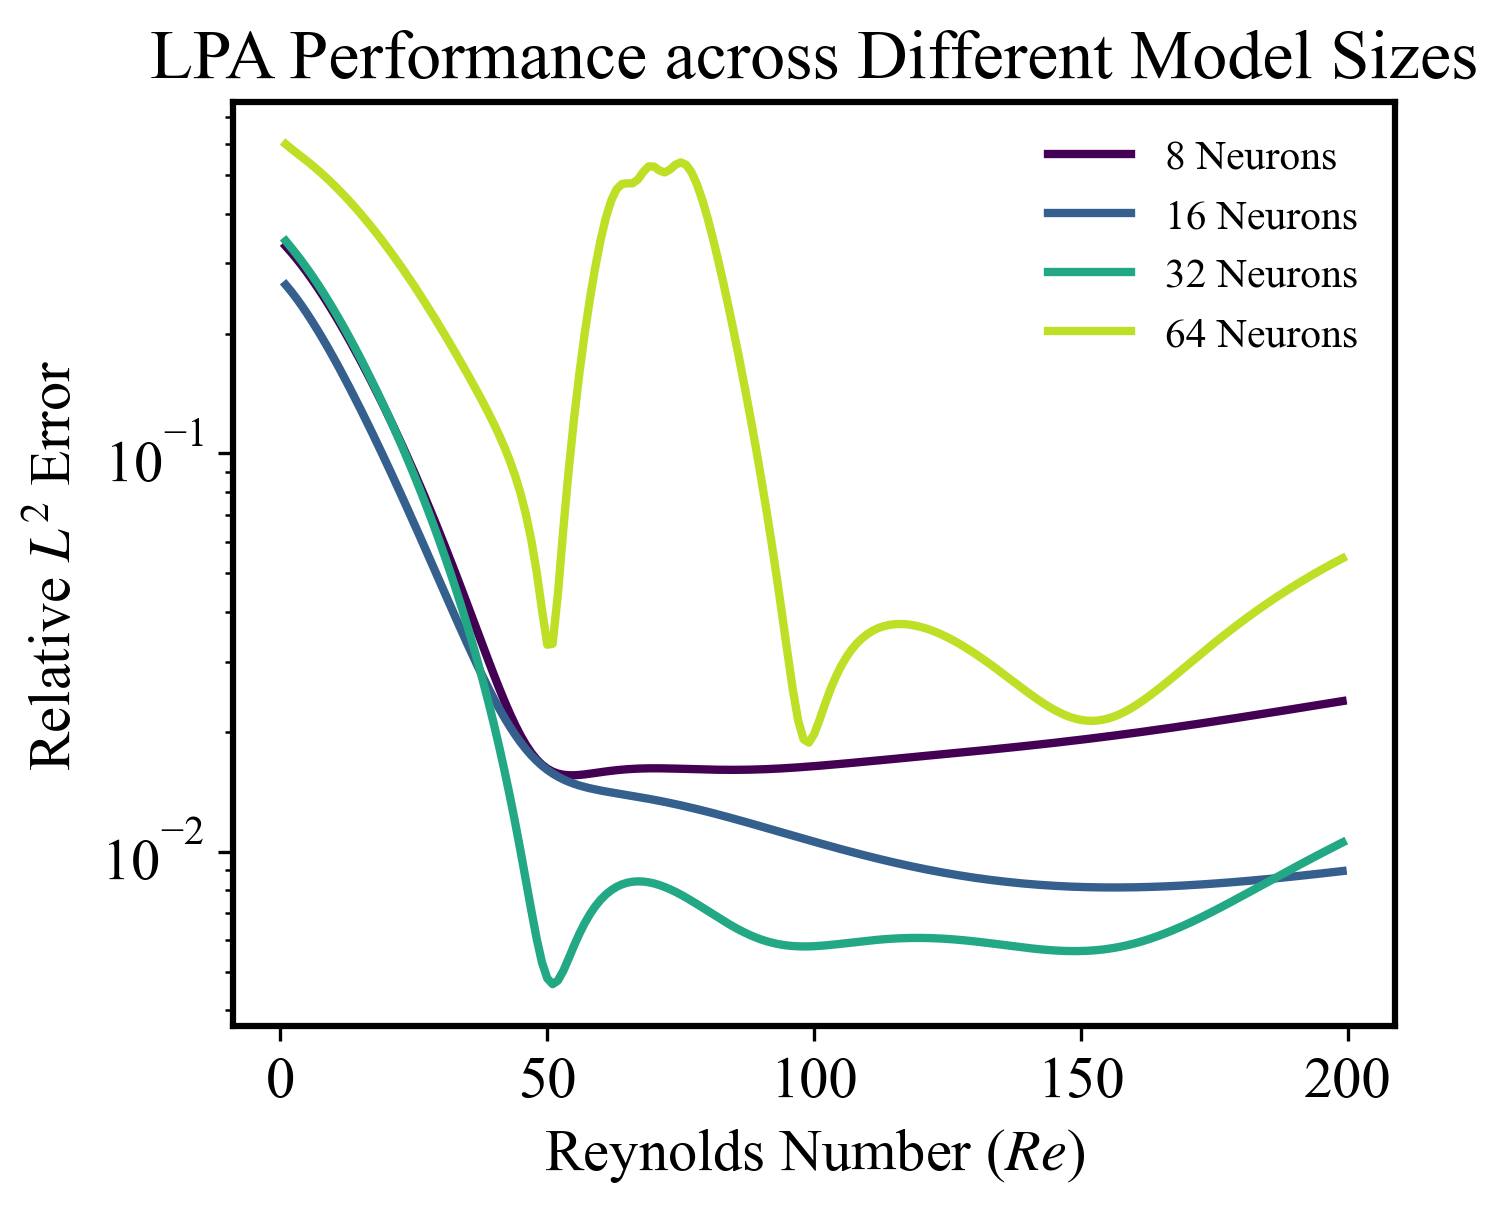

In [4]:
# ==========================================
# 4. 시각화 (그래프 그리기)
# ==========================================
# 구조별로 그래프를 그립니다.
arch_list = sorted(list(all_data.keys()), key=lambda x: int(x.split('_')[1])) # 뉴런 수 순서 정렬

if not arch_list:
    print("데이터를 찾을 수 없습니다. 경로를 확인해주세요.")
else:
    # -------------------------------------------------------
    # Plot 1: 아키텍처별 LPA vs Vanilla 성능 비교 (Subplots)
    # -------------------------------------------------------
    num_archs = len(arch_list)
    fig, axes = plt.subplots(1, num_archs, figsize=(5 * num_archs, 4), constrained_layout=True)
    if num_archs == 1: axes = [axes]

    for idx, arch in enumerate(arch_list):
        ax = axes[idx]
        models = all_data[arch]
        
        # 모델별 Plot
        for m_type in ["VAN", "LPA"]: # 순서 고정
            if m_type not in models: continue
            
            res_dict = models[m_type]
            if not res_dict: continue
            
            # Re 순서대로 정렬
            sorted_re = sorted(res_dict.keys())
            sorted_err = [res_dict[r] for r in sorted_re]
            
            style = 'o-' if m_type == "LPA" else 's--'
            color = 'green' if m_type == "LPA" else 'orange'
            label = f"{m_type} ({arch})"
            
            ax.plot(sorted_re, sorted_err, style, label=label, color=color, markersize=5, alpha=0.8)

        ax.set_yscale('log')
        ax.set_title(f"Architecture: {arch.replace('_', ' Layers, ')} Neurons")
        ax.set_xlabel("Reynolds Number ($Re$)")
        ax.set_ylabel("Relative $L^2$ Error")
        ax.tick_params(axis='both', which='major', direction='in', labelsize=14, top=True, right=True)
        ax.tick_params(axis='both', which='minor', labelsize=14, left=False, right=False)
        ax.set_ylim(1e-4, 1.0)
        ax.legend()

    plt.suptitle("Performance Comparison: LPA vs Vanilla by Architecture", fontsize=16)
    plt.show()

    # -------------------------------------------------------
    # Plot 2: 모든 구조의 LPA 성능 한눈에 비교 (Lightweight 효과 확인)
    # -------------------------------------------------------
    plt.figure(figsize=(5, 4))
    
    colors = plt.cm.viridis(np.linspace(0, 0.9, len(arch_list)))
    
    for idx, arch in enumerate(arch_list):
        if "LPA" not in all_data[arch]: continue
        
        res_dict = all_data[arch]["LPA"]
        if not res_dict: continue
        
        sorted_re = sorted(res_dict.keys())
        sorted_err = [res_dict[r] for r in sorted_re]
        
        # 뉴런 수 파싱 (범례용)
        layers, neurons = arch.split('_')
        
        plt.plot(sorted_re, sorted_err, '-', 
                 label=f"{neurons} Neurons", 
                 color=colors[idx], linewidth=2)

    plt.yscale('log')
    plt.title("LPA Performance across Different Model Sizes")
    plt.xlabel("Reynolds Number ($Re$)")
    plt.ylabel("Relative $L^2$ Error")
    plt.grid(False)
    plt.legend(fontsize=10, frameon=False, loc='best')
    plt.show()

In [5]:
import os
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ==========================================
# 1. 스타일 설정 (논문용 깔끔한 스타일)
# ==========================================
mpl.rcParams['font.family'] = 'Times New Roman' # 한글 폰트가 필요하면 변경 (예: 'Malgun Gothic')
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.size'] = 14
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['lines.linewidth'] = 2.0
mpl.rcParams['figure.dpi'] = 300

# ==========================================
# 2. 결과 데이터 로드 및 에러 계산 함수
# ==========================================
def parse_re_from_filename(filename):
    """파일명에서 Re 값 추출 (예: ...Re50.0.txt -> 50.0)"""
    match = re.search(r"Re([\d\.]+)\.txt", filename)
    return float(match.group(1)) if match else None

def compute_relative_l2(pred, exact):
    """Relative L2 Error 계산"""
    # 벡터 형태(N, 1) 혹은 (N,) 등으로 들어올 수 있음
    diff = pred.flatten() - exact.flatten()
    norm_diff = np.linalg.norm(diff)
    norm_exact = np.linalg.norm(exact.flatten())
    if norm_exact < 1e-9: return 0.0
    return norm_diff / norm_exact

def load_all_results(root_dir="./results"):
    """
    구조: results/{layers}_{neurons}/{KEY}/...
    반환: data[arch][model_type] = {Re: error, ...}
    """
    data_summary = {} # { "3_8": {"LPA+PIDeepOnet": {50.0: 0.01, ...}, "PIDeepOnet": ...}, "3_16": ... }

    # 1. 아키텍처 폴더 탐색 (예: 3_8, 3_16 ...)
    arch_folders = sorted(glob.glob(os.path.join(root_dir, "*_*")))

    for arch_path in arch_folders:
        arch_name = os.path.basename(arch_path) # "3_8"
        if not re.match(r"\d+_\d+", arch_name): continue

        data_summary[arch_name] = {}

        # 2. 모델 타입 폴더 탐색 (DeepONet_PINN_B_LPA 등)
        model_folders = glob.glob(os.path.join(arch_path, "DeepONet_*"))
        
        for model_path in model_folders:
            model_dir_name = os.path.basename(model_path)
            
            # 모델 타입 식별 (LPA+PIDeepOnet vs PIDeepOnet)
            # 기존 VAN -> PIDeepOnet, LPA -> LPA+PIDeepOnet 으로 매핑
            if "LPA" in model_dir_name:
                m_type = "LPA+PIDeepOnet"
            elif "PIDeepOnet" in model_dir_name or "VAN" in model_dir_name:
                m_type = "PIDeepOnet"
            else:
                continue
            
            if m_type not in data_summary[arch_name]:
                data_summary[arch_name][m_type] = {}

            # 3. 예측/정답 파일 쌍 찾기
            pred_files = glob.glob(os.path.join(model_path, "prediction_*_Re*.txt"))
            
            for f_pred in pred_files:
                re_val = parse_re_from_filename(f_pred)
                if re_val is None: continue

                # 대응되는 exact 파일 찾기
                f_exact = f_pred.replace("prediction_", "exact_")
                
                if not os.path.exists(f_exact):
                    # exact 파일이 없으면 계산 스킵 (혹은 별도 계산 로직 필요)
                    continue

                try:
                    # 데이터 로드 (csv 형태 가정)
                    pred_data = np.loadtxt(f_pred, delimiter=',')
                    exact_data = np.loadtxt(f_exact, delimiter=',')
                    
                    # u, v, p가 합쳐져 있을 수 있음 (여기서는 전체 벡터에 대한 L2 계산)
                    # 만약 u만 보고 싶다면 인덱싱 필요 (예: pred_data[:, 0])
                    # 여기서는 전체 필드(u,v,p 통합) 에러를 계산합니다.
                    err = compute_relative_l2(pred_data, exact_data)
                    data_summary[arch_name][m_type][re_val] = err
                except Exception as e:
                    print(f"Error loading {f_pred}: {e}")

    return data_summary


In [6]:
# ==========================================
# 3. 데이터 로딩 실행
# ==========================================
results_root = "./results"  # 결과가 저장된 루트 폴더
all_data = load_all_results(results_root)

print("Loaded Architectures:", list(all_data.keys()))
for arch in all_data:
    print(f"  [{arch}] Models: {list(all_data[arch].keys())}")

Loaded Architectures: ['3_16', '3_32', '3_64', '3_8']
  [3_16] Models: ['LPA+PIDeepOnet', 'PIDeepOnet']
  [3_32] Models: ['LPA+PIDeepOnet', 'PIDeepOnet']
  [3_64] Models: ['LPA+PIDeepOnet', 'PIDeepOnet']
  [3_8] Models: ['LPA+PIDeepOnet', 'PIDeepOnet']


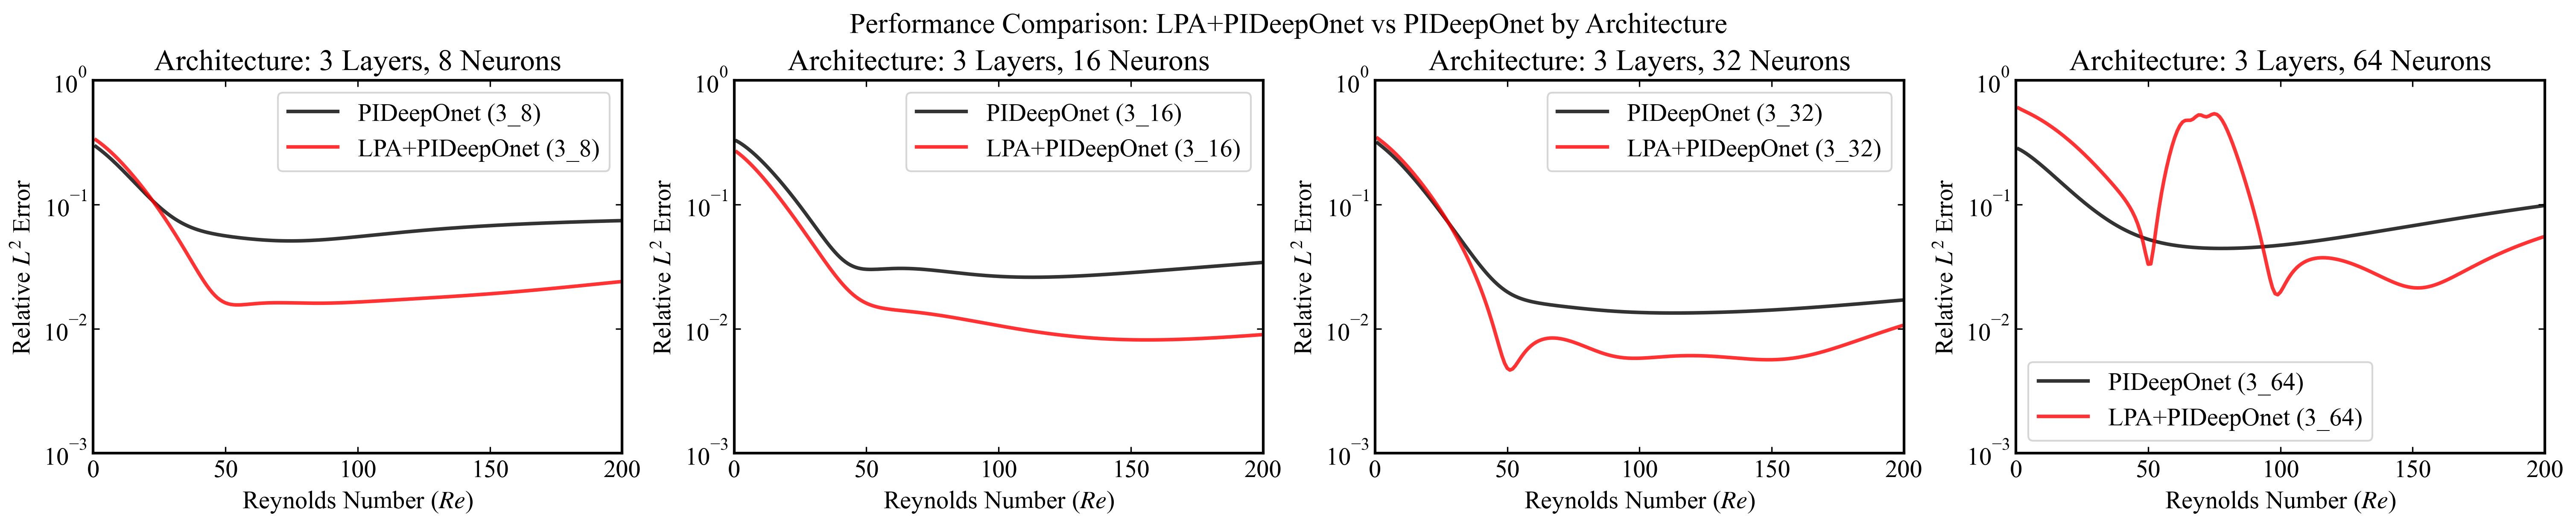

In [7]:
# ==========================================
# 4. 시각화 (그래프 그리기)
# ==========================================
# 구조별로 그래프를 그립니다.
arch_list = sorted(list(all_data.keys()), key=lambda x: int(x.split('_')[1])) # 뉴런 수 순서 정렬

if not arch_list:
    print("데이터를 찾을 수 없습니다. 경로를 확인해주세요.")
else:
    # -------------------------------------------------------
    # Plot 1: 아키텍처별 PIDeepOnet vs LPA+PIDeepOnet 성능 비교 (Subplots)
    # -------------------------------------------------------
    num_archs = len(arch_list)
    fig, axes = plt.subplots(1, num_archs, figsize=(5 * num_archs, 4), constrained_layout=True)
    if num_archs == 1: axes = [axes]

    for idx, arch in enumerate(arch_list):
        ax = axes[idx]
        models = all_data[arch]
        
        # 모델별 Plot
        target_models = ["PIDeepOnet", "LPA+PIDeepOnet"]
        for m_type in target_models: # 순서 고정
            if m_type not in models: continue
            
            res_dict = models[m_type]
            if not res_dict: continue
            
            # Re 순서대로 정렬
            sorted_re = sorted(res_dict.keys())
            sorted_err = [res_dict[r] for r in sorted_re]
            
            is_lpa = "LPA" in m_type
            style = '-' if is_lpa else '-'
            color = 'red' if is_lpa else 'black'
            label = f"{m_type} ({arch})"
            
            ax.plot(sorted_re, sorted_err, style, label=label, color=color, markersize=5, alpha=0.8)

        ax.set_yscale('log')
        ax.set_title(f"Architecture: {arch.replace('_', ' Layers, ')} Neurons")
        ax.set_xlabel("Reynolds Number ($Re$)")
        ax.set_ylabel("Relative $L^2$ Error")
        ax.tick_params(axis='both', which='major', direction='in', labelsize=14, top=True, right=True)
        ax.tick_params(axis='both', which='minor', labelsize=14, left=False, right=False)
        ax.set_xlim(0, 200)
        ax.set_ylim(1e-3, 1.0)
        ax.legend()

    plt.suptitle("Performance Comparison: LPA+PIDeepOnet vs PIDeepOnet by Architecture", fontsize=16)
    plt.show()

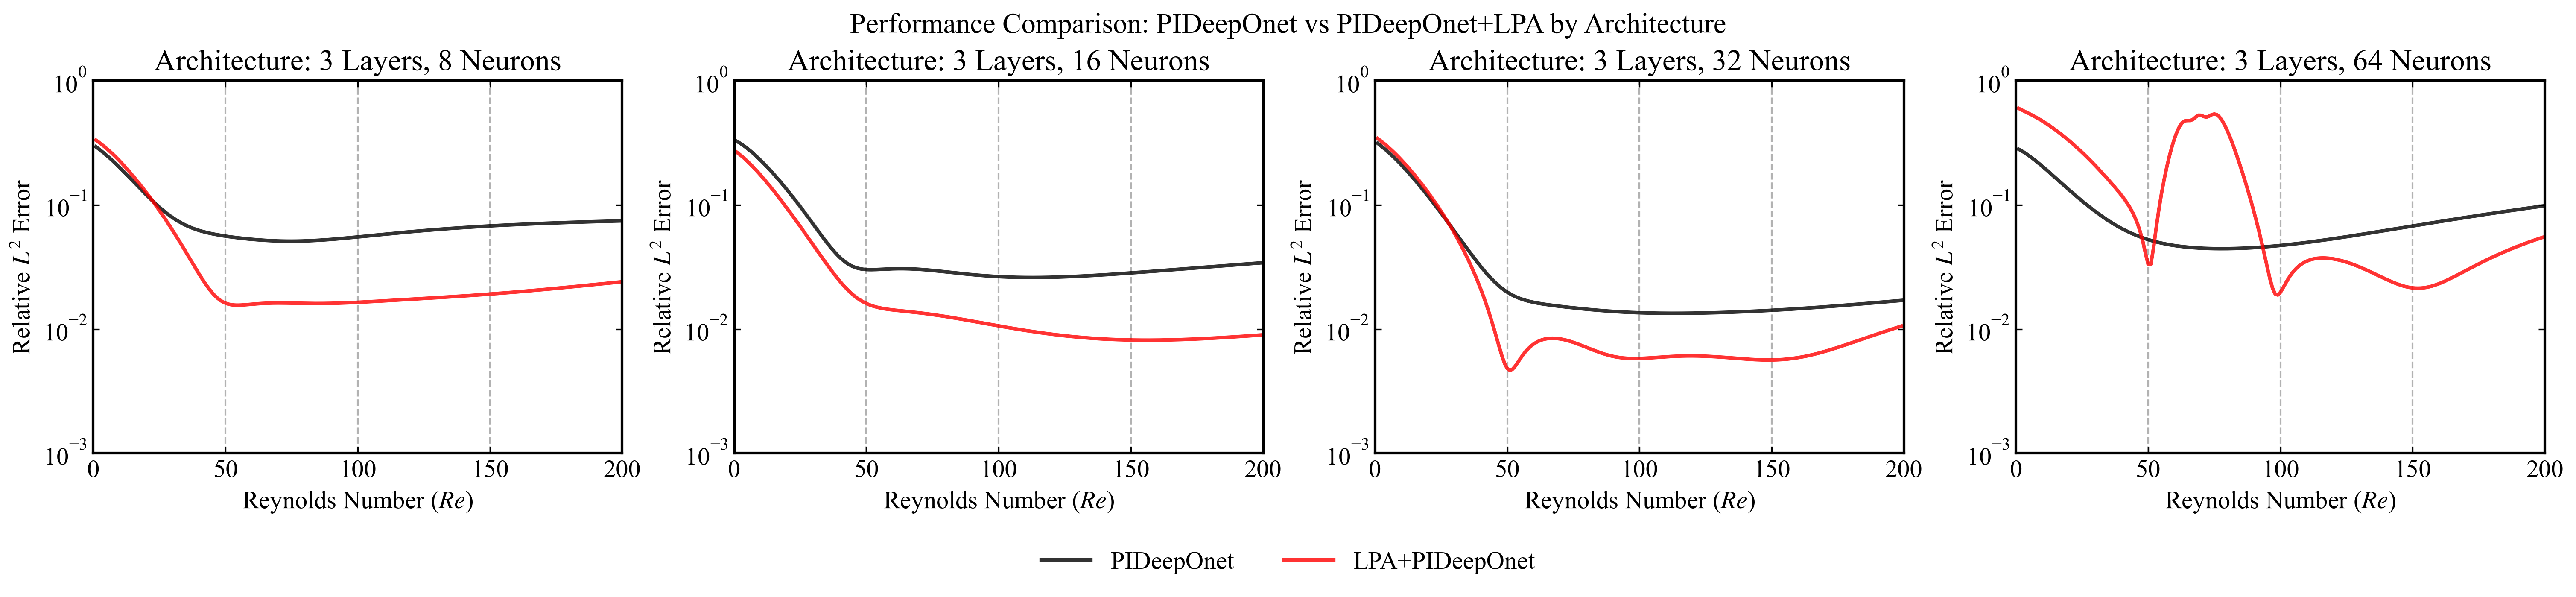

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# ==========================================
# 4. 시각화 (그래프 그리기)
# ==========================================
# 구조별로 그래프를 그립니다.
arch_list = sorted(list(all_data.keys()), key=lambda x: int(x.split('_')[1])) # 뉴런 수 순서 정렬

if not arch_list:
    print("데이터를 찾을 수 없습니다. 경로를 확인해주세요.")
else:
    # -------------------------------------------------------
    # Plot 1: 아키텍처별 PIDeepOnet vs LPA+PIDeepOnet 성능 비교 (Subplots)
    # -------------------------------------------------------
    num_archs = len(arch_list)
    fig, axes = plt.subplots(1, num_archs, figsize=(5 * num_archs, 4), constrained_layout=True)
    if num_archs == 1: axes = [axes]

    # 글로벌 범례용 핸들과 라벨 리스트
    global_handles = []
    global_labels = []

    for idx, arch in enumerate(arch_list):
        ax = axes[idx]
        models = all_data[arch]
        
        # 1) 훈련 포인트 (50, 100, 150) 수직 점선 추가
        training_points = [50, 100, 150]
        for tp in training_points:
            # zorder=0으로 설정하여 데이터 라인 뒤쪽에 그려지게 함
            ax.axvline(x=tp, color='gray', linestyle='--', linewidth=1.0, alpha=0.6, zorder=0)

        # 2) 모델별 Plot
        target_models = ["PIDeepOnet", "LPA+PIDeepOnet"]
        for m_type in target_models: # 순서 고정
            if m_type not in models: continue
            
            res_dict = models[m_type]
            if not res_dict: continue
            
            # Re 순서대로 정렬
            sorted_re = sorted(res_dict.keys())
            sorted_err = [res_dict[r] for r in sorted_re]
            
            is_lpa = "LPA" in m_type
            # 사용자 지정 스타일 적용
            style = '-'  # 둘 다 실선
            color = 'red' if is_lpa else 'black'
            
            # 라벨은 모델 이름만 (구조 정보 제외)
            label = m_type 
            
            line, = ax.plot(sorted_re, sorted_err, style, label=label, color=color, markersize=5, alpha=0.8)
            
            # 글로벌 범례에 추가 (중복 방지)
            if label not in global_labels:
                global_labels.append(label)
                global_handles.append(line)

        ax.set_yscale('log')
        ax.set_title(f"Architecture: {arch.replace('_', ' Layers, ')} Neurons")
        ax.set_xlabel("Reynolds Number ($Re$)")
        ax.set_ylabel("Relative $L^2$ Error")
        
        # 축 스타일 설정
        ax.tick_params(axis='both', which='major', direction='in', labelsize=14, top=True, right=True)
        ax.tick_params(axis='both', which='minor', labelsize=14, left=False, right=False)
        
        ax.set_xlim(0, 200)
        ax.set_ylim(1e-3, 1.0)
        
        # 개별 subplot 범례 제거 (하단 통합 범례 사용)
        # ax.legend() 

    # 3) 전체 그래프 하단 중앙에 통합 범례 생성
    # 훈련 포인트 점선에 대한 범례를 추가하고 싶다면 핸들을 직접 추가 가능하지만, 
    # 여기서는 모델 두 개만 깔끔하게 표시합니다.
    fig.legend(global_handles, global_labels, loc='lower center', 
               bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False, fontsize=14)
    
    plt.suptitle("Performance Comparison: PIDeepOnet vs PIDeepOnet+LPA by Architecture", fontsize=16)
    plt.show()

In [10]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# ==========================================
# 1. 스타일 설정
# ==========================================
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.size'] = 14
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['lines.linewidth'] = 2.0
mpl.rcParams['figure.dpi'] = 300

# ==========================================
# 2. 결과 데이터 로드 함수 (results_compare/metrics.csv 기반)
# ==========================================
def load_all_results(root_dir="./results_compare"):
    """
    구조: results_compare/{layers}_{neurons}/metrics.csv
    CSV 컬럼: label, Re, l1_u, l1_v, l1_p, l2_u, l2_v, l2_p
    반환: data[arch][model_type][re_val] = {'u': ..., 'v': ..., 'p': ...}
    """
    data_summary = {} 

    # 1. 아키텍처 폴더 탐색 (예: 3_8, 3_16 ...)
    arch_folders = sorted(glob.glob(os.path.join(root_dir, "*_*")))

    if not arch_folders:
        print(f"Warning: No architecture folders found in {root_dir}")

    for arch_path in arch_folders:
        arch_name = os.path.basename(arch_path) 
        # 폴더명이 "숫자_숫자" 형식이 아니면 스킵
        if not re.match(r"\d+_\d+", arch_name): continue

        data_summary[arch_name] = {}

        # 2. metrics.csv 파일 경로 (아키텍처 폴더 바로 아래)
        csv_path = os.path.join(arch_path, "metrics.csv")
        
        if not os.path.exists(csv_path):
            print(f"  [Skip] metrics.csv not found in {arch_name}")
            continue

        try:
            # CSV 읽기
            df = pd.read_csv(csv_path)
            
            # 컬럼 이름 공백 제거 (예: " label" -> "label")
            df.columns = [c.strip() for c in df.columns]
            
            # 행 단위로 데이터 추출
            for _, row in df.iterrows():
                # 라벨(모델명) 추출 및 공백 제거
                raw_label = str(row['label']).strip()
                
                # [중요] CSV의 라벨을 시각화용 이름으로 매핑
                if raw_label == "LPA": 
                    m_type = "LPA+PIDeepOnet"
                elif raw_label == "PID": 
                    m_type = "PIDeepOnet"
                elif raw_label == "SUP": 
                    m_type = "Supervised" # 필요 시 사용
                else: 
                    m_type = raw_label # 매핑 없으면 그대로 사용

                if m_type not in data_summary[arch_name]:
                    data_summary[arch_name][m_type] = {}
                
                re_val = float(row['Re'])
                
                # u, v, p 에러 저장
                errs = {
                    'u': float(row['l2_u']),
                    'v': float(row['l2_v']),
                    'p': float(row['l2_p'])
                }
                
                data_summary[arch_name][m_type][re_val] = errs
            
            print(f"  [Loaded] {arch_name}: Found {len(df)} rows")
                
        except Exception as e:
            print(f"Error loading {csv_path}: {e}")

    return data_summary

In [11]:
# 데이터 로드 실행
results_root = "./results_compare"  # 폴더 경로 확인
all_data = load_all_results(results_root)

# 로드된 데이터 확인
print("\n=== Data Summary ===")
for arch in all_data:
    print(f"Architecture: {arch}")
    print(f"  Models: {list(all_data[arch].keys())}")

  [Loaded] 3_16: Found 597 rows
  [Loaded] 3_32: Found 597 rows
  [Loaded] 3_8: Found 597 rows

=== Data Summary ===
Architecture: 3_16
  Models: ['Supervised', 'PIDeepOnet', 'LPA+PIDeepOnet']
Architecture: 3_32
  Models: ['Supervised', 'PIDeepOnet', 'LPA+PIDeepOnet']
Architecture: 3_8
  Models: ['Supervised', 'PIDeepOnet', 'LPA+PIDeepOnet']


  [Loaded] 3_16: Found 597 rows
  [Loaded] 3_32: Found 597 rows
  [Loaded] 3_8: Found 597 rows

=== Data Summary ===
Architecture: 3_16
  Models: ['Supervised', 'PIDeepOnet', 'LPA+PIDeepOnet']
Architecture: 3_32
  Models: ['Supervised', 'PIDeepOnet', 'LPA+PIDeepOnet']
Architecture: 3_8
  Models: ['Supervised', 'PIDeepOnet', 'LPA+PIDeepOnet']


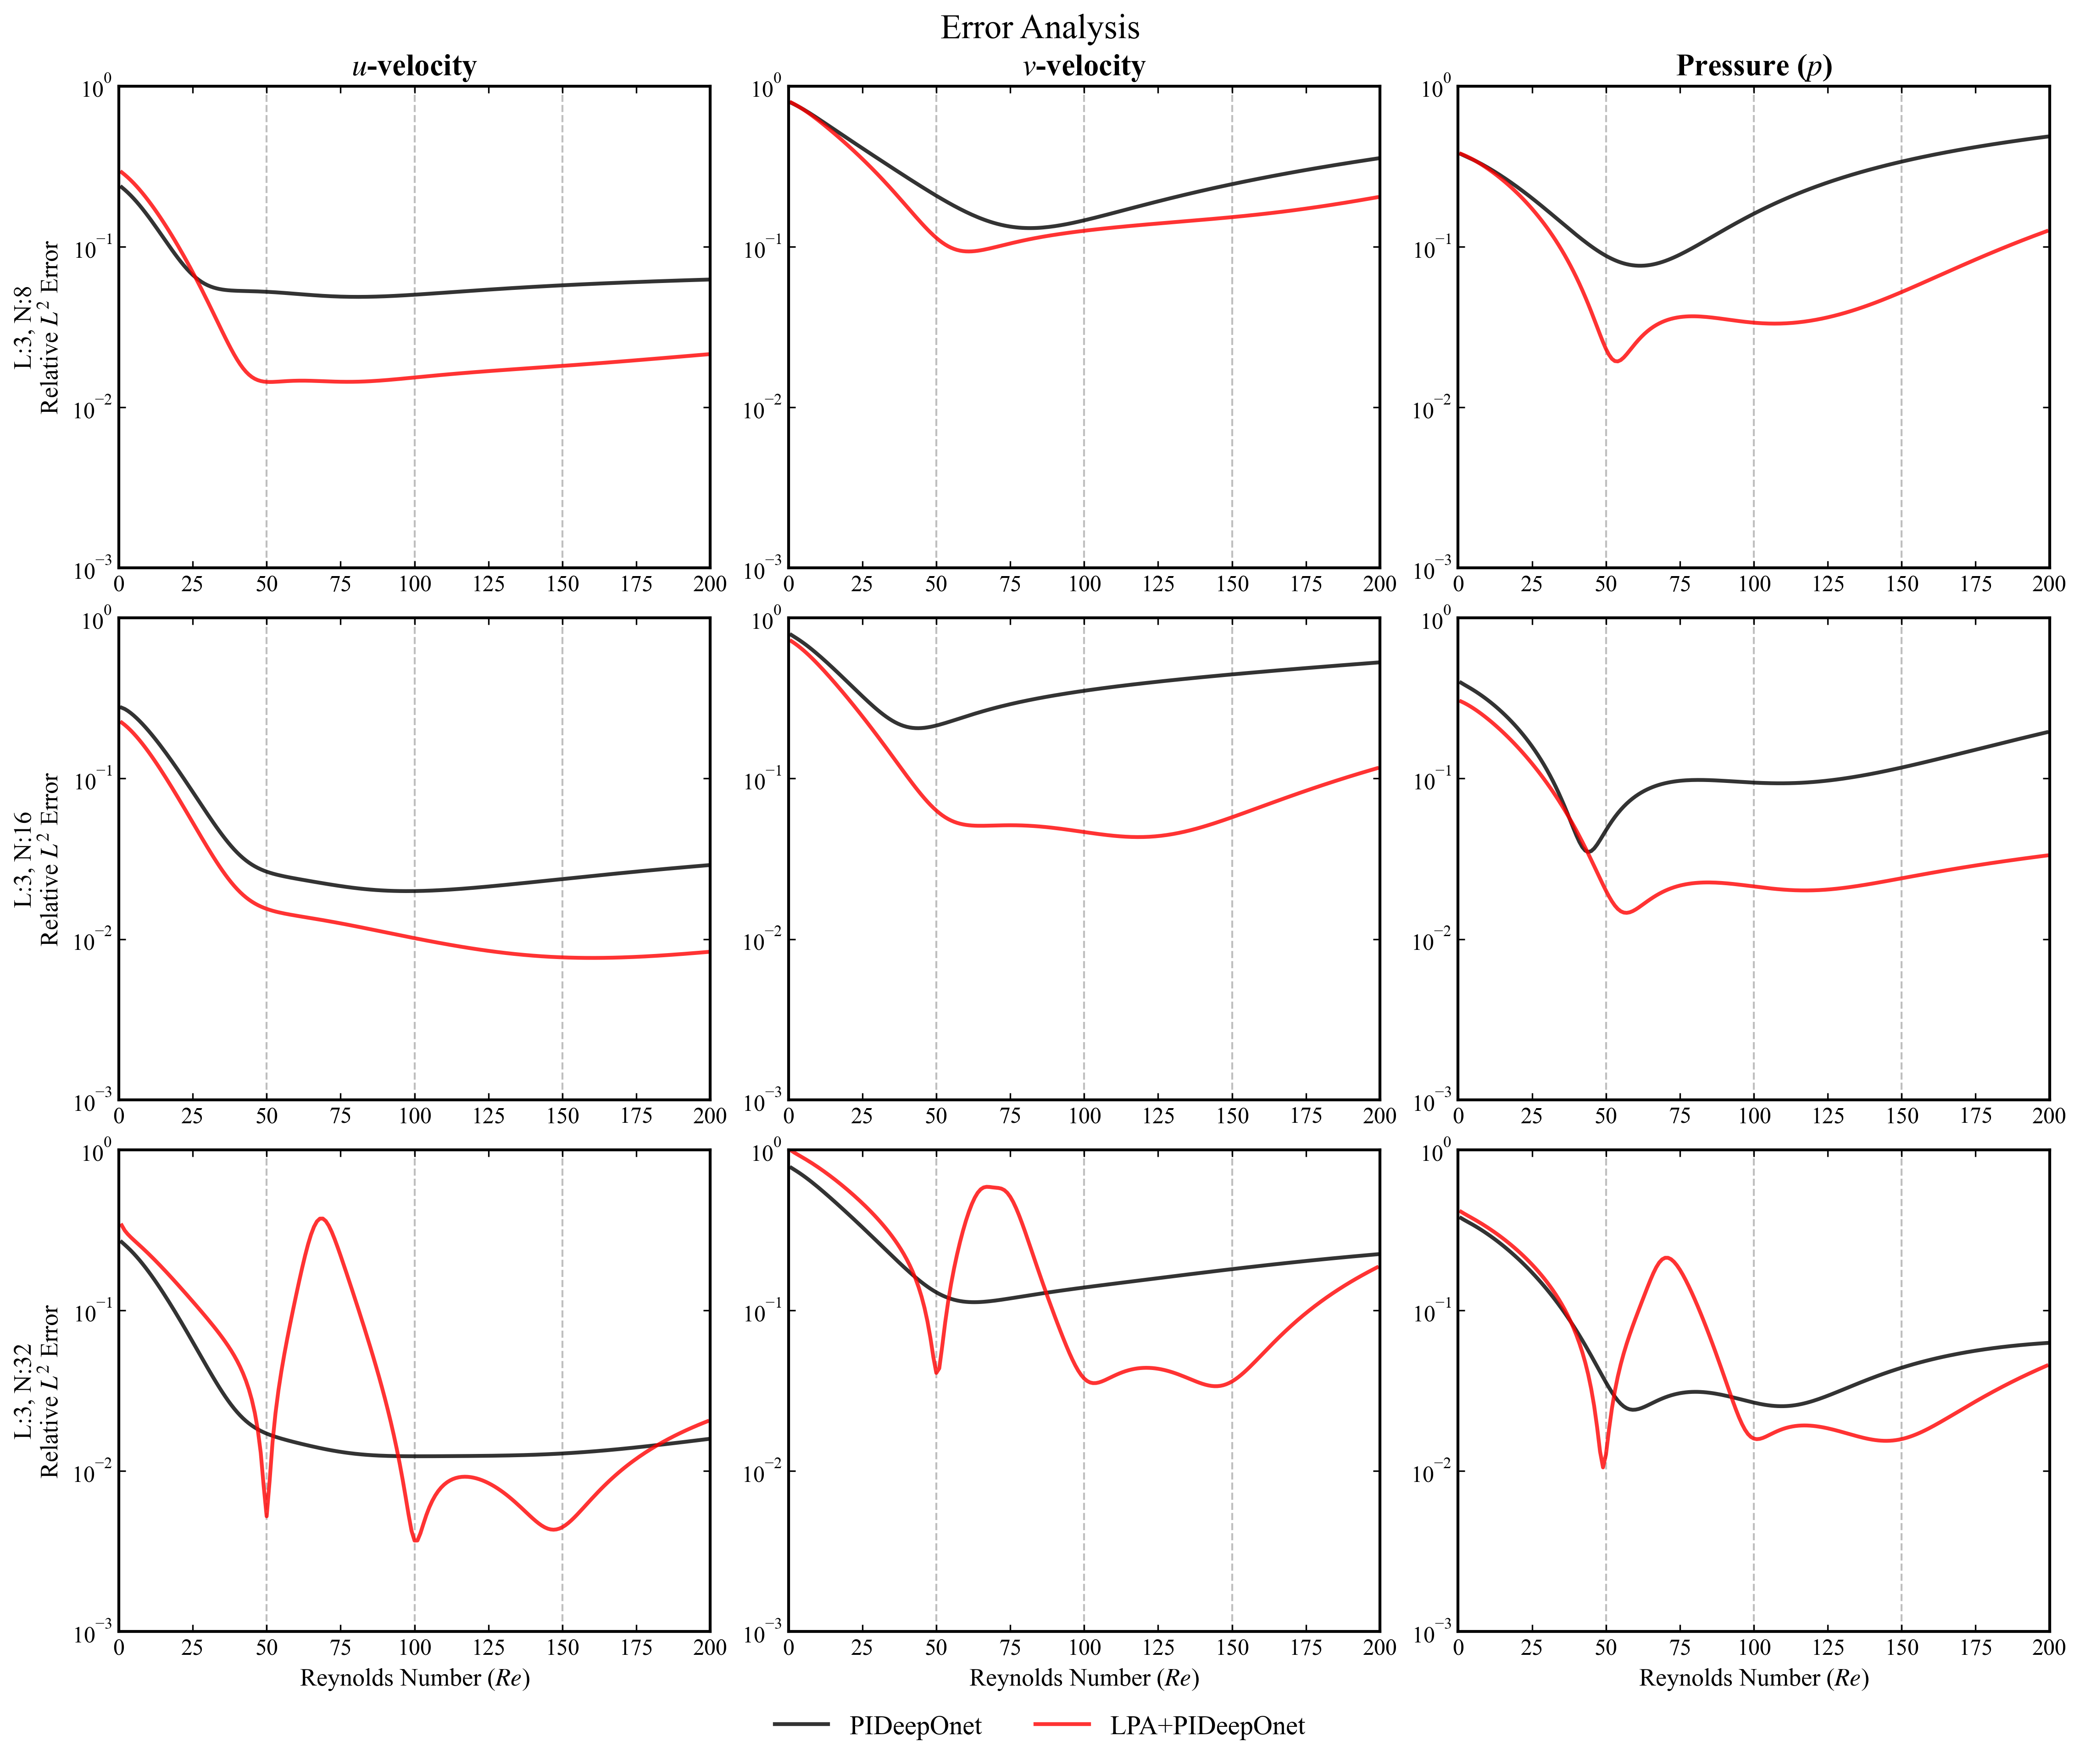

In [15]:
# 데이터 로드 실행
results_root = "./results_compare"  # 폴더 경로 확인
all_data = load_all_results(results_root)

# 로드된 데이터 확인
print("\n=== Data Summary ===")
for arch in all_data:
    print(f"Architecture: {arch}")
    print(f"  Models: {list(all_data[arch].keys())}")

# ==========================================
# 4. 시각화 (행: 아키텍처, 열: u, v, p)
# ==========================================
arch_list = sorted(list(all_data.keys()), key=lambda x: int(x.split('_')[1]))

if not arch_list:
    print("데이터를 찾을 수 없습니다.")
else:
    num_archs = len(arch_list)
    variables = ['u', 'v', 'p']
    var_labels = {'u': '$u$-velocity', 'v': '$v$-velocity', 'p': 'Pressure ($p$)'}
    
    # 설정: 행(Architecture) x 열(u, v, p)
    # 한 행(아키텍처)의 높이를 약 4인치, 한 열(변수)의 너비를 약 5인치로 설정
    fig, axes = plt.subplots(num_archs, 3, figsize=(15, 4 * num_archs), constrained_layout=True)
    
    # 아키텍처가 1개일 경우를 대비해 2차원 배열로 고정
    if num_archs == 1:
        axes = np.expand_dims(axes, axis=0)

    global_handles = []
    global_labels = []

    for r, arch in enumerate(arch_list):
        for c, var in enumerate(variables):
            ax = axes[r, c]
            models = all_data[arch]
            
            # 1) 훈련 포인트 (50, 100, 150) 수직 점선
            training_points = [50, 100, 150]
            for tp in training_points:
                ax.axvline(x=tp, color='gray', linestyle='--', linewidth=1.0, alpha=0.5, zorder=0)

            # 2) 모델별 Plot
            target_models = ["PIDeepOnet", "LPA+PIDeepOnet"]
            for m_type in target_models:
                if m_type not in models: continue
                
                res_dict = models[m_type]
                if not res_dict: continue
                
                sorted_re = sorted(res_dict.keys())
                sorted_err = [res_dict[re_val].get(var, np.nan) for re_val in sorted_re]
                
                is_lpa = "LPA" in m_type
                color = 'red' if is_lpa else 'black'
                
                line, = ax.plot(sorted_re, sorted_err, '-', label=m_type, color=color, alpha=0.8)
                
                # 범례 수집 (최초 1회만)
                if m_type not in global_labels:
                    global_labels.append(m_type)
                    global_handles.append(line)

            # --- 서브플롯 디테일 설정 ---
            ax.set_yscale('log')
            ax.set_xlim(0, 200)
            ax.set_ylim(1e-3, 1.0) # 에러 범위에 따라 조정 가능
            
            # 맨 윗줄에만 물리량(u, v, p) 타이틀 표시
            if r == 0:
                ax.set_title(var_labels[var], fontsize=16, fontweight='bold')
            
            # 각 행의 첫 번째 열에만 아키텍처 정보 표시 (Y축 라벨 대용)
            if c == 0:
                layers, neurons = arch.split('_')
                ax.set_ylabel(f"L:{layers}, N:{neurons}\nRelative $L^2$ Error", fontsize=13)
            else:
                ax.set_ylabel("")

            # 맨 아랫줄에만 X축 라벨(Re) 표시
            if r == num_archs - 1:
                ax.set_xlabel("Reynolds Number ($Re$)", fontsize=13)
            
            ax.tick_params(axis='both', which='major', direction='in', labelsize=12, top=True, right=True)
            ax.tick_params(axis='both', which='minor', direction='in', labelsize=12, top=False, left=False)
    # 통합 범례 (그래프 최하단)
    fig.legend(global_handles, global_labels, loc='lower center', 
               bbox_to_anchor=(0.5, -0.12 / num_archs), ncol=2, frameon=False, fontsize=14)
    
    plt.suptitle("Error Analysis", fontsize=18, y=1.02)
    plt.show()

In [13]:
import numpy as np
import pandas as pd
import os

# ==========================================
# 1. 설정 (Configuration)
# ==========================================
result_dir = './results'  # 결과 파일이 있는 경로

# 비교할 모델의 파일명 키워드 (실제 파일명 패턴에 맞춤)
# Label: 파일명에 포함된 식별자
models = {
    'PID': 'DeepONet_PINN_B_VAN',
    'LPA': 'DeepONet_PINN_B_LPA'
}

# 비교할 아키텍처 리스트 (Layers, Neurons)
configs = [(3, 8), (3, 16), (3, 32), (3, 64)]

# ==========================================
# 2. 데이터 추출 함수
# ==========================================
def get_best_trial_data(layers, neurons, model_key, n_trials=10):
    best_data = {
        'L2_u': np.inf, 'L2_v': np.inf, 'L2_p': np.inf,
        'Time': None, 'Trial': None
    }

    for trial in range(n_trials):
        # 파일 경로 설정 (사용자 패턴 반영)
        acc_file = f'{result_dir}/acc_hist_{layers}_{neurons}_{model_key}_{trial}.txt'
        time_file = f'{result_dir}/cal_time_{layers}_{neurons}_{model_key}_{trial}.txt'

        if not os.path.exists(acc_file):
            continue

        try:
            # 1. 정확도 데이터 읽기
            acc_hist = np.loadtxt(acc_file, delimiter=',')
            if acc_hist.ndim == 1: continue 
            
            # 마지막 Epoch의 L2 Error 가져오기 (u, v, p 순서 가정)
            # 파일 포맷: [L1_u, L1_v, L1_p, L2_u, L2_v, L2_p, ...] 라고 가정
            curr_l2_u = acc_hist[-1, 3]
            curr_l2_v = acc_hist[-1, 4]
            curr_l2_p = acc_hist[-1, 5]

            # 2. 시간 데이터 읽기
            curr_time = np.nan
            if os.path.exists(time_file):
                # 파일에 숫자 하나만 들어있는 경우 대응
                t_data = np.loadtxt(time_file, delimiter=',')
                curr_time = float(t_data) if t_data.ndim == 0 else np.sum(t_data)

            # 3. Best Trial 갱신 (u, v, p 합산 에러가 가장 낮은 것을 선택하거나, u 기준 선택)
            # 여기서는 u 에러를 기준으로 Best를 선정합니다.
            if curr_l2_u < best_data['L2_u']:
                best_data = {
                    'L2_u': curr_l2_u,
                    'L2_v': curr_l2_v,
                    'L2_p': curr_l2_p,
                    'Time': curr_time,
                    'Trial': trial
                }
        except Exception as e:
            print(f"Error reading {acc_file}: {e}")
            continue
            
    return best_data

# ==========================================
# 3. 메인 로직 및 테이블 생성
# ==========================================
rows = []

for layers, neurons in configs:
    # 1. PID 데이터 가져오기
    pid_res = get_best_trial_data(layers, neurons, models['PID'])
    
    # 2. LPA 데이터 가져오기
    lpa_res = get_best_trial_data(layers, neurons, models['LPA'])
    
    # 3. 데이터가 둘 다 없으면 스킵
    if pid_res['Trial'] is None and lpa_res['Trial'] is None:
        continue

    # 4. 행(Row) 추가
    row = {
        'Arch': f"{layers}L / {neurons}N",
        
        # PID Stats
        'PID L2(u)': pid_res['L2_u'],
        'PID L2(v)': pid_res['L2_v'],
        'PID L2(p)': pid_res['L2_p'],
        'PID Time(s)': pid_res['Time'],
        
        # LPA Stats
        'LPA L2(u)': lpa_res['L2_u'],
        'LPA L2(v)': lpa_res['L2_v'],
        'LPA L2(p)': lpa_res['L2_p'],
        'LPA Time(s)': lpa_res['Time'],
    }
    
    # 5. 시간 증가율 (Ratio) 계산: LPA Time / PID Time
    if pid_res['Time'] is not None and lpa_res['Time'] is not None and pid_res['Time'] > 0:
        row['Time Ratio'] = lpa_res['Time'] / pid_res['Time']
    else:
        row['Time Ratio'] = np.nan
        
    rows.append(row)

# DataFrame 생성
df = pd.DataFrame(rows)

# ==========================================
# 4. 결과 출력 (논문용 포맷팅)
# ==========================================

# 출력 옵션 설정 (소수점 포맷)
pd.options.display.float_format = '{:.2e}'.format

# 컬럼 순서 재정렬 (보기 좋게)
cols_order = [
    'Arch', 
    'PID L2(u)', 'LPA L2(u)', 
    'PID L2(v)', 'LPA L2(v)', 
    'PID L2(p)', 'LPA L2(p)', 
    'PID Time(s)', 'LPA Time(s)', 'Time Ratio'
]

# 만약 데이터가 없어서 컬럼이 안 생겼을 경우 대비
existing_cols = [c for c in cols_order if c in df.columns]
df_final = df[existing_cols]

print("\n[ Table: Comparison of Error and Computational Cost ]")
print("-" * 120)
# DataFrame을 문자열로 변환하여 출력 (Index 제외)
print(df_final.to_string(index=False, formatters={
    'PID Time(s)': '{:.1f}'.format,
    'LPA Time(s)': '{:.1f}'.format,
    'Time Ratio': '{:.1f}x'.format
}))
print("-" * 120)

# CSV로 저장 (선택 사항)
# df_final.to_csv("comparison_table.csv", index=False)
# print("Table saved to 'comparison_table.csv'")


[ Table: Comparison of Error and Computational Cost ]
------------------------------------------------------------------------------------------------------------------------
    Arch  PID L2(u)  LPA L2(u)  PID L2(v)  LPA L2(v)  PID L2(p)  LPA L2(p) PID Time(s) LPA Time(s) Time Ratio
 3L / 8N   3.33e-02   1.84e-02   5.31e-02   1.98e-02   2.71e-01   1.78e-01       134.6       185.0       1.4x
3L / 16N   1.05e-02   1.37e-02   3.46e-02   2.05e-02   2.10e-01   1.04e-01       184.0       226.8       1.2x
3L / 32N   2.14e-02   1.44e-02   2.33e-02   3.32e-02   1.79e-01   2.08e-01       248.6       674.9       2.7x
3L / 64N   2.26e-02   6.20e-02   6.17e-02   1.06e-01   1.91e-01   3.30e-01       402.1       473.2       1.2x
------------------------------------------------------------------------------------------------------------------------
